In [2]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.spatial.transform import Rotation as R
from simulator.utils.plots import *

In [3]:
%matplotlib widget

In [4]:
m = 0.045  # kg
g = 9.81  # m/s^2
L = 0.035  # m
J = np.diag([2.3951e-5, 2.3951e-5, 3.2347e-5])  # kg m^2

In [5]:
#df = pd.read_parquet("data/real/new/parquets/melon_20251017_run1.parquet")
#df = pd.read_parquet("data/real/new/parquets/square_20251017_run1.parquet")
df = pd.read_parquet("../data/real/raw/parquets/square_20251017_run2.parquet")
#df = pd.read_parquet("data/real/new/parquets/random1_20251017_run1.parquet")

# Thrust/accelerations calculations

In [6]:
df.columns

Index(['t', 'x', 'y', 'z', 'qx', 'qy', 'qz', 'qw', 'yaw', 'pitch', 'roll',
       'vx', 'vy', 'vz', 'wx', 'wy', 'wz', 'ros_timestamp_x', 'x_mocap',
       'y_mocap', 'z_mocap', 'qx_mocap', 'qy_mocap', 'qz_mocap', 'qw_mocap',
       'yaw_mocap', 'pitch_mocap', 'roll_mocap', 'm1_thrust', 'm2_thrust',
       'm3_thrust', 'm4_thrust', 'm1_erpm', 'm2_erpm', 'm3_erpm', 'm4_erpm',
       'ros_timestamp_y', 'thrust', 'torque_roll', 'torque_pitch', 'torch_yaw',
       'ax', 'ay', 'az', 'ros_timestamp', 'x_r', 'y_r', 'z_r', 'qx_r', 'qy_r',
       'qz_r', 'qw_r', 'yaw_r', 'pitch_r', 'roll_r', 'vx_r', 'vy_r', 'vz_r',
       'wx_r', 'wy_r', 'wz_r', 'ros_timestamp_r', 'Vbat', 'can_be_armed',
       'is_armed', 'auto_arm', 'can_fly', 'is_flying', 'is_tumbled',
       'is_locked'],
      dtype='object')

In [7]:
ts = df["t"].diff().median(); ts

np.float64(0.009999999999999787)

In [8]:
fs = 1 / ts; fs

np.float64(100.00000000000213)

In [9]:
# A low-pass Butterworth filter design
fc = 20.0         # Cutoff frequency in continuous-time (Hz)
order = 4         # Filter order
b_butter, a_butter = scipy.signal.butter(order, fc, btype='low', analog=False, fs=fs)

def filter_signals(data):
    signals = data.shape[1]
    filtered = np.zeros_like(data)
    for i in range(signals):
        filtered[:, i] = scipy.signal.filtfilt(b_butter, a_butter, data[:, i])
    return filtered

In [10]:
time_vec = df["t"].values

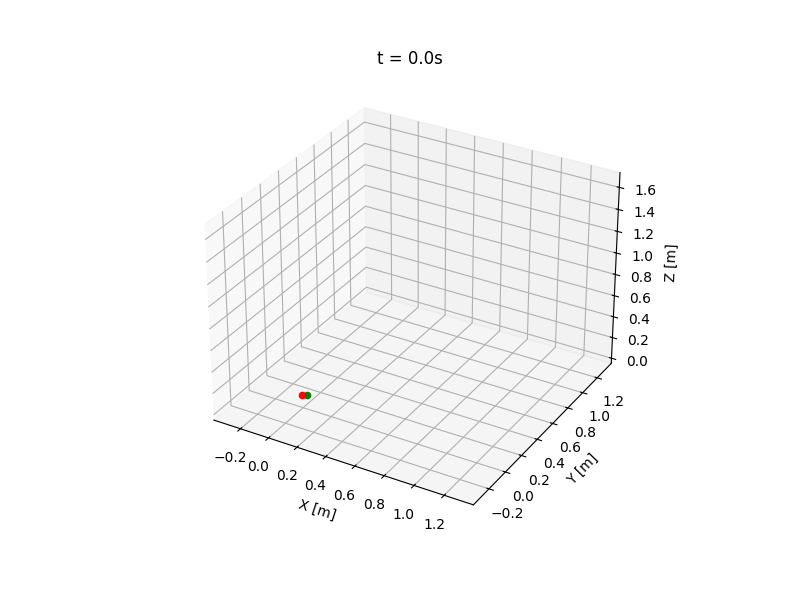

In [12]:
sub = 1
anim = animate_trajectory(df, des_df=None, subsample=sub)
#anim.save("sim_rot.mp4", writer="ffmpeg", fps=1/ts/sub)

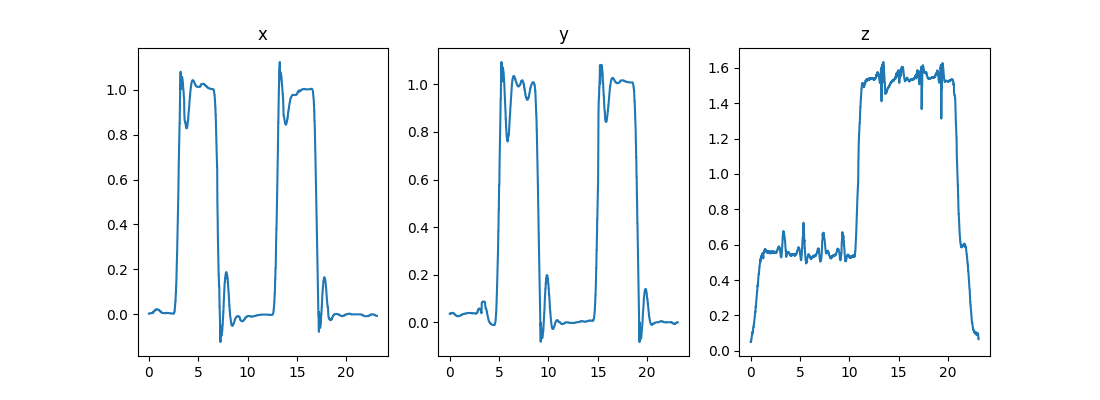

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(11, 4))

ax[0].set_title("x")
ax[0].plot(time_vec, df["x"])

ax[1].set_title("y")
ax[1].plot(time_vec, df["y"])

ax[2].set_title("z")
ax[2].plot(time_vec, df["z"])
plt.show()

In [14]:
quat = df[["qx", "qy", "qz", "qw"]].values
r = R.from_quat(quat)
ag_wf = df[["ax", "ay", "az"]].values
ag_bf = r.apply(ag_wf, inverse=True) #to body frame
T_bf = ag_bf * m * g

T_bf_f = filter_signals(T_bf)

In [15]:
motors  = df[["m1_erpm", "m2_erpm", "m3_erpm", "m4_erpm"]].values

In [16]:
motors_fill = df[["m1_erpm", "m2_erpm", "m3_erpm", "m4_erpm"]].ffill().values
motors_f = filter_signals(motors_fill)
motors_filt_df = pd.DataFrame(motors_f, columns=["m1_erpm", "m2_erpm", "m3_erpm", "m4_erpm"])

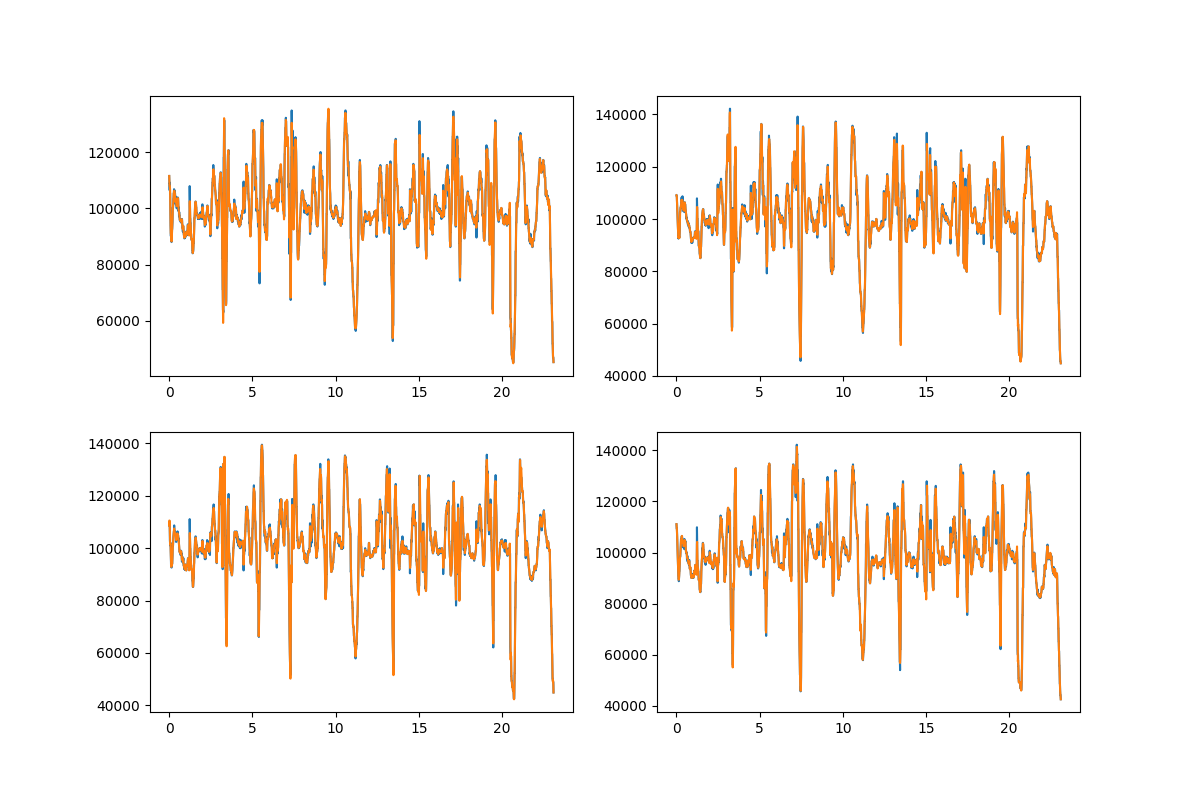

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].plot(time_vec, motors[:, 0], label="m1")
ax[0, 1].plot(time_vec, motors[:, 1], label="m2")
ax[1, 0].plot(time_vec, motors[:, 2], label="m3")
ax[1, 1].plot(time_vec, motors[:, 3], label="m4")

ax[0, 0].plot(time_vec, motors_f[:, 0], label="m1 filt")
ax[0, 1].plot(time_vec, motors_f[:, 1], label="m2 filt")
ax[1, 0].plot(time_vec, motors_f[:, 2], label="m3 filt")
ax[1, 1].plot(time_vec, motors_f[:, 3], label="m4 filt")
plt.show()
plt.legend()

In [ ]:
T_mot = np.sum(motors**2, axis=1)
T_mot_f = np.sum(motors_f**2, axis=1)

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
ax[0].plot(time_vec, ag_bf, label="$\vec a$")
ax[1].plot(time_vec, T_mot, label="T");
plt.legend()
#

$$\mathbf{T} = m \mathbf{a} + m\mathbf{g} = m\overbrace{(a + g)}^{\text{quantity measured by accelerometer}}$$

In [ ]:
#start_idx = np.searchsorted(time_vec, 46.6) # some points with thrust on
#stop_idx = np.searchsorted(time_vec, 68.0)
start_idx = 100
stop_idx = len(time_vec) - 100

In [ ]:
idx = df["t"] > 40
lag = 0
plt.figure()
plt.scatter(T_mot[start_idx-lag:stop_idx-lag], T_bf[start_idx:stop_idx, 2], c=time_vec[start_idx:stop_idx], cmap="viridis", s=1)
plt.xlabel("Thrust regressor ")
plt.ylabel("Measured thrust (body z-axis)");

# TODO check whether fit can be further improved with a shift - compute cross-correlation

In [ ]:
idx = df["t"] > 40
lag = 0
plt.figure()
plt.scatter(T_mot_f[start_idx-lag:stop_idx-lag], T_bf_f[start_idx:stop_idx, 2], c=time_vec[start_idx:stop_idx], cmap="viridis", s=1)
plt.xlabel("Thrust regressor")
plt.ylabel("Measured thrust (body z-axis)");

# TODO check whether fit can be further improved with a shift - compute cross-correlation

## Torques / angular accelerations

In [ ]:
# Approach I: smoothening and differentiating the gyroscope data

expected_std = 0.1 # standard dev
N = df["t"].size
weight = 1/expected_std
wx_fun = scipy.interpolate.make_splrep(df["t"], df["wx"], w=np.full(N, fill_value=weight), s=N)
wy_fun = scipy.interpolate.make_splrep(df["t"], df["wy"], w=np.full(N, fill_value=weight), s=N)
wz_fun = scipy.interpolate.make_splrep(df["t"], df["wz"], w=np.full(N, fill_value=weight), s=N)

#wys = scipy.interpolate.make_splrep(df["t"], df["wy"],  s=0)
#wzs = scipy.interpolate.make_splrep(df["t"], df["wz"],  s=0)

wxd_fun = wx_fun.derivative()
wyd_fun = wy_fun.derivative()
wzd_fun = wz_fun.derivative()

In [ ]:
# Approach II: filtering the gyroscope data
fc = 10.0         # Cutoff frequency in continuous-time (Hz)
order = 4         # Filter order
b_butter, a_butter = scipy.signal.butter(order, fc, btype='low', analog=False, fs=fs)

angular_vel_filt = filter_signals(df[["wx", "wy", "wz"]].values)
angular_acc_filt = np.gradient(angular_vel_filt, ts, axis=0)

In [ ]:
# Approach II: differentiationg the pose

qx_fun = scipy.interpolate.make_splrep(df["t"], df["qx"],  s=1e-2)
qy_fun = scipy.interpolate.make_splrep(df["t"], df["qy"],  s=1e-2)
qz_fun = scipy.interpolate.make_splrep(df["t"], df["qz"],  s=1e-2)
qw_fun = scipy.interpolate.make_splrep(df["t"], df["qw"],  s=1e-2)

qxd_fun = qx_fun.derivative()
qyd_fun = qy_fun.derivative()
qzd_fun = qz_fun.derivative()
qwd_fun = qw_fun.derivative()

qxd = qxd_fun(df["t"])
qyd = qyd_fun(df["t"])
qzd = qzd_fun(df["t"])
qwd = qwd_fun(df["t"])

q = df[["qx", "qy", "qz", "qw"]].values
qdot = np.vstack([qxd, qyd, qzd, qwd]).T
#qdot = np.gradient(q, 0.01, axis=0)


def quat_to_omega_body(q, qdot):
    """
    Vectorized conversion from quaternion derivative to body angular velocity.
    
    q, qdot : arrays of shape (N, 4) with ordering [qx, qy, qz, qw]
    returns omega_body : shape (N, 3)
    """

    qv = q[:, :3]        # (N,3)
    qw = q[:, 3:4]       # (N,1)
    dqv = qdot[:, :3]    # (N,3)
    dqw = qdot[:, 3:4]   # (N,1)

    # Cross product is vectorized by NumPy
    cross = np.cross(qv, dqv)   # (N,3)

    omega = 2.0 * (qw * dqv - dqw * qv - cross)  # (N,3)

    return omega


angular_vel_odom = quat_to_omega_body(q, qdot)
angular_acc_odom = np.gradient(angular_vel_odom, ts, axis=0)

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Angular Velocities")
ax[0].plot(df["t"], df["wx"], label="gyro")
ax[0].plot(df["t"], wx_fun(df["t"]), label="smoothed gyro")
ax[0].plot(df["t"], angular_vel_filt[:, 0], label="filt gyro")
ax[0].plot(df["t"], angular_vel_odom[:, 0], label="odom diff")
ax[0].legend()

ax[1].plot(df["t"], df["wy"], label="gyro")
ax[1].plot(df["t"], wy_fun(df["t"]), label="smoothed gyro")
ax[1].plot(df["t"], angular_vel_odom[:, 1], label="odom diff")
ax[1].legend()

ax[2].plot(df["t"], df["wz"], label="gyro")
ax[2].plot(df["t"], wz_fun(df["t"]), label="smoothed gyro")
ax[2].plot(df["t"], angular_vel_odom[:, 2], label="odom diff")
ax[2].legend()

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Angular Accelerations")
ax[0].plot(df["t"], wxd_fun(df["t"]), label="smoothed gyro diff")
ax[0].plot(df["t"], angular_acc_filt[:, 0], label="filtered gyro diff")
ax[0].plot(df["t"], angular_acc_odom[:, 0], label="odom 2nd diff")
ax[0].plot(df["t"], angular_acc_odom[:, 0], label="odom 2nd diff")
ax[0].legend()

ax[1].plot(df["t"], wyd_fun(df["t"]), label="smoothed")
ax[1].plot(df["t"], angular_acc_odom[:, 1], label="odom 2nd diff")
ax[1].legend()

ax[2].plot(df["t"], wz_fun(df["t"]), label="smoothed")
ax[2].plot(df["t"], angular_acc_odom[:, 2], label="odom 2nd diff")
ax[2].legend();

$$ \dot \omega = J^{-1} \left( \tau - \omega \times (J\omega) \right)$$

$$ \tau = J \dot \omega + \omega \times (J\omega) $$

In [ ]:
omegas = df[["wx", "wy", "wz"]].values
domegas =  np.stack([wxd_fun(df["t"]), wyd_fun(df["t"]), wzd_fun(df["t"])]).T

tau_1 = domegas @ J.T # J \dot \omega 
Jomegas = omegas @ J.T 
tau_2 = np.cross(omegas, Jomegas) # \omega \times (J \omega)
tau_meas = tau_1 + tau_2

In [ ]:
tx_mot = df["m3_erpm"]**2 + df["m4_erpm"]**2 - df["m1_erpm"]**2 - df["m2_erpm"]**2 
ty_mot = df["m3_erpm"]**2 + df["m2_erpm"]**2 - df["m4_erpm"]**2 - df["m1_erpm"]**2 

tx_mot = tx_mot.values
ty_mot = ty_mot.values

In [ ]:
tx_mot_f = motors_filt_df["m3_erpm"]**2 + motors_filt_df["m4_erpm"]**2 - motors_filt_df["m1_erpm"]**2 - motors_filt_df["m2_erpm"]**2 
ty_mot_f = motors_filt_df["m3_erpm"]**2 + motors_filt_df["m2_erpm"]**2 - motors_filt_df["m4_erpm"]**2 - motors_filt_df["m1_erpm"]**2 

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

#ax[0].plot(tau_1[:, 0], label='tau_1')
#ax[0].plot(tau_2[:, 0], label='tau_2')
ax[0].plot(time_vec, tau_meas[:, 0], label=r'$\tau$')
axt = ax[0].twinx()
axt.plot(time_vec, tx_mot, label=r'$\tau_m$', color="C2")
ax[0].legend(loc ='upper left')
axt.legend(loc='upper right')

ax[1].plot(time_vec, tau_meas[:, 1], label=r'$\tau_{12}$')
axt = ax[1].twinx()
axt.plot(time_vec, ty_mot, label=r'$\tau_m$', color="C2")
ax[1].legend(loc ='upper left')
axt.legend(loc='upper right')

# ax[2].plot(torques[:, 2], label='torques')
# ax[2].plot(tau_1[:, 2], label='tau_1')
# ax[2].plot(tau_2[:, 2], label='tau_2')
# ax[2].plot(tau_12[:, 2], label='tau_12')
plt.show()

In [ ]:
lag = 3
plt.figure()
plt.plot(tx_mot[start_idx-lag:stop_idx-lag], wxd_fun(time_vec[start_idx:stop_idx]), "*")
plt.show()

In [ ]:
lag = 4
plt.figure()
plt.plot(tx_mot[start_idx-lag:stop_idx-lag], angular_acc_odom[start_idx:stop_idx, 0], "*")
plt.show()

In [ ]:
lag = 4
plt.figure()
plt.plot(tx_mot[start_idx-lag:stop_idx-lag], angular_acc_filt[start_idx-lag:stop_idx-lag, 0], "*")
plt.show()

In [ ]:
lag = 4
plt.figure()
plt.plot(ty_mot[start_idx-lag:stop_idx-lag], wyd_fun(time_vec[start_idx:stop_idx]), "*")
plt.show()

In [ ]:
lag = 3
plt.figure()
plt.plot(ty_mot[start_idx-lag:stop_idx-lag], angular_acc_odom[start_idx:stop_idx, 1], "*")
plt.show()

In [ ]:
lag = 3
plt.figure()
plt.plot(tx_mot_f[start_idx-lag:stop_idx-lag], angular_acc_filt[start_idx:stop_idx, 0], "*")
plt.show()

In [ ]:
lag = 3
plt.figure()
plt.plot(ty_mot_f[start_idx-lag:stop_idx-lag], angular_acc_filt[start_idx:stop_idx, 1], "*")
plt.show()